# Spaceship Titanic 생존자 예측. 
작성자: 오성우

## 목차

1. [EDA + Preprocessing](##1. EDA + Preprocessing)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# 1. EDA + Preprocessing

In [23]:
import os
from os.path import join
from pathlib import Path
data_dir = Path('./data')

train_data_path = join(data_dir, 'train.csv')
test_data_path = join(data_dir, 'test.csv')

train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)

train.shape

(8693, 14)

In [24]:
test.shape

(4277, 13)

### 데이터를 확인합니다

#### 직관적으로 꼭 필요해보이는것
HomePlanet - 출발위치
Destination - 목적지
결국 이것이 경로가되어 차원이동이 필요한지가 결정될수 있음.

CryoSleep - 동면 격리 여부
차원이동 할때 필요할지도?

----------------------------------------------------
#### 나머지 고려사항

Cabin - deck/num/side

PassengerId - gggg_pp 형태 gggg=그룹 pp=승객

deck

side P(좌측) S(우측)

Age

VIP

RoomService, FoodCourt, ShoppingMall, Spa, VRDeck

----------------------------------------------------
#### 필요 없어 보이는것


Name 

----------------------------------------------------

Transported - 차원이동 여부 (우리가 찾아야하는 값)

In [25]:
train.head(30)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


### 1-1 Missing Data 결측치
결측치가 너무 많네요ㅠ

In [26]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


#### 1-1-1 먼저 기내에서 돈을 쓴사람은 동면상태가 아니라고 채워줌

In [27]:
# 1. 지출 관련 컬럼 리스트
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 2. 지출 합계 계산 (결측치는 0으로 간주하고 합산)
total_spend = train[exp_cols].sum(axis=1)

# 3. CryoSleep이 결측치이면서, 지출 합계가 0보다 큰 경우 False로 채움
train.loc[train['CryoSleep'].isnull() & (total_spend > 0), 'CryoSleep'] = False
test.loc[test['CryoSleep'].isnull() & (total_spend > 0), 'CryoSleep'] = False

#### 1-1-2 동면중인사람은 지출을 모두 0으로 처리

In [28]:
for col in exp_cols:
    train.loc[(train['CryoSleep'] == True) & (train[col].isnull()), col] = 0
    test.loc[(test['CryoSleep'] == True) & (test[col].isnull()), col] = 0

In [29]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      201
CryoSleep        98
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     113
FoodCourt       113
ShoppingMall    112
Spa             118
VRDeck          126
Name            200
Transported       0
dtype: int64


#### 1-1-3 id의 그룹정보를 가지고 출발지 HomePlanet Destination 통일시키기

In [30]:
# PassengerId의 앞 4자리를 추출하여 'Group' 컬럼 생성
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0])
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0])

# 각 그룹별로 가장 많이 나타나는 HomePlanet과 Destination을 찾아 매칭
for col in ['HomePlanet', 'Destination']:
    # 그룹별 최빈값으로 결측치를 채움 (그룹 내 정보가 있는 경우)
    train[col] = train[col].fillna(train.groupby('Group')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))
    test[col] = test[col].fillna(test.groupby('Group')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

#### 1-1-4 HomePlanet, Destination, VIP의 전체 최빈값 구하기

In [31]:
hp_mode = train['HomePlanet'].mode()[0]
dest_mode = train['Destination'].mode()[0]
vip_mode = train['VIP'].mode()[0]
print( hp_mode, dest_mode, vip_mode)

Earth TRAPPIST-1e False


#### 1-1-5 VIP 는 일정금액이상 지출한사람은 true로 처리 아닌사람은 모두 False

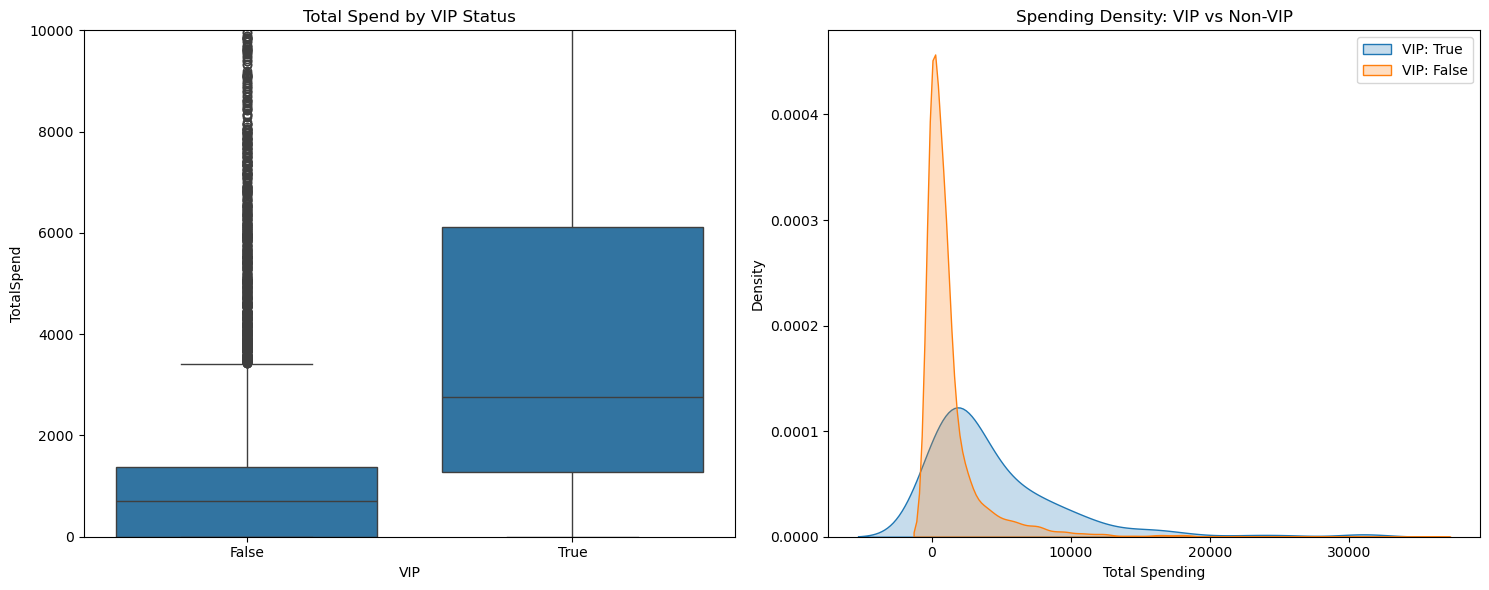

In [32]:
# 1. 이미 계산된 total_spend 변수를 train 데이터프레임에 삽입
train['TotalSpend'] = total_spend

# 2. 시각화 설정
plt.figure(figsize=(15, 6))

# [그래프 1] VIP 여부에 따른 지출 분포 (Boxplot)
plt.subplot(1, 2, 1)
# y축 값을 'TotalSpend' 컬럼으로 지정
sns.boxplot(data=train.dropna(subset=['VIP']), x='VIP', y='TotalSpend')
plt.title('Total Spend by VIP Status')
plt.ylim(0, 10000) # 데이터 분포에 따라 범위를 조절해 보세요.

# [그래프 2] 지출액에 따른 VIP 밀도 (KDE Plot)
plt.subplot(1, 2, 2)
# 각 VIP 조건에 맞는 데이터의 'TotalSpend'를 x축으로 시각화
sns.kdeplot(data=train[train['VIP'] == True], x='TotalSpend', label='VIP: True', fill=True)
sns.kdeplot(data=train[train['VIP'] == False], x='TotalSpend', label='VIP: False', fill=True)
plt.title('Spending Density: VIP vs Non-VIP')
plt.xlabel('Total Spending')
plt.legend()

plt.tight_layout()
plt.show()

Train VIP 지출확인

In [33]:
# 1. VIP와 Non-VIP 데이터 분리 (결측치 제외)
vip_true = train[train['VIP'] == True]
vip_false = train[train['VIP'] == False]

# 2. 전체 숫자 파악
total_vip_count = len(vip_true)
total_non_vip_count = len(vip_false)

print(f"--- [VIP 분석 (총 {total_vip_count}명)] ---")
# 1-1. 4000 이상 지출한 VIP 비율
v_over_4000 = len(vip_true[vip_true['TotalSpend'] >= 4000])
print(f"1. 4000이상 지출 VIP: {v_over_4000}명 / 비율: {v_over_4000/total_vip_count:.2%}")

# 1-2. 4000 이하 지출한 VIP 비율
v_under_4000 = len(vip_true[vip_true['TotalSpend'] < 4000])
print(f"2. 4000미만 지출 VIP: {v_under_4000}명 / 비율: {v_under_4000/total_vip_count:.2%}")

# 1-3. 2000 이하 지출한 VIP 비율
v_under_2000 = len(vip_true[vip_true['TotalSpend'] < 2000])
print(f"3. 2000미만 지출 VIP: {v_under_2000}명 / 비율: {v_under_2000/total_vip_count:.2%}")

print(f"\n--- [Non-VIP 분석 (총 {total_non_vip_count}명)] ---")
# 2-1. 4000 이상 지출한 Non-VIP 비율
nv_over_4000 = len(vip_false[vip_false['TotalSpend'] >= 4000])
print(f"1. 4000이상 지출 Non-VIP: {nv_over_4000}명 / 비율: {nv_over_4000/total_non_vip_count:.2%}")

# 2-2. 4000 이하 지출한 Non-VIP 비율
nv_under_4000 = len(vip_false[vip_false['TotalSpend'] < 4000])
print(f"2. 4000미만 지출 Non-VIP: {nv_under_4000}명 / 비율: {nv_under_4000/total_non_vip_count:.2%}")

# 2-3. 2000 이하 지출한 Non-VIP 비율
nv_under_2000 = len(vip_false[vip_false['TotalSpend'] < 2000])
print(f"3. 2000미만 지출 Non-VIP: {nv_under_2000}명 / 비율: {nv_under_2000/total_non_vip_count:.2%}")

--- [VIP 분석 (총 199명)] ---
1. 4000이상 지출 VIP: 73명 / 비율: 36.68%
2. 4000미만 지출 VIP: 126명 / 비율: 63.32%
3. 2000미만 지출 VIP: 80명 / 비율: 40.20%

--- [Non-VIP 분석 (총 8291명)] ---
1. 4000이상 지출 Non-VIP: 739명 / 비율: 8.91%
2. 4000미만 지출 Non-VIP: 7552명 / 비율: 91.09%
3. 2000미만 지출 Non-VIP: 6773명 / 비율: 81.69%


Test VIP 지출 확인

In [34]:
# 0. Test용 TotalSpend 열 생성
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
test['TotalSpend'] = test[exp_cols].sum(axis=1)

# 1. VIP와 Non-VIP 데이터 분리 (test 데이터 기준, 결측치 제외)
vip_true_test = test[test['VIP'] == True]
vip_false_test = test[test['VIP'] == False]

# 2. 전체 숫자 파악
total_vip_count_test = len(vip_true_test)
total_non_vip_count_test = len(vip_false_test)

print(f"--- [TEST 세트 VIP 분석 (총 {total_vip_count_test}명)] ---")
if total_vip_count_test > 0:
    # 1-1. 4000 이상 지출한 VIP 비율
    v_over_4000 = len(vip_true_test[vip_true_test['TotalSpend'] >= 4000])
    print(f"1. 4000이상 지출 VIP: {v_over_4000}명 / 비율: {v_over_4000/total_vip_count_test:.2%}")

    # 1-2. 4000 이하 지출한 VIP 비율
    v_under_4000 = len(vip_true_test[vip_true_test['TotalSpend'] < 4000])
    print(f"2. 4000미만 지출 VIP: {v_under_4000}명 / 비율: {v_under_4000/total_vip_count_test:.2%}")

    # 1-3. 2000 이하 지출한 VIP 비율
    v_under_2000 = len(vip_true_test[vip_true_test['TotalSpend'] < 2000])
    print(f"3. 2000미만 지출 VIP: {v_under_2000}명 / 비율: {v_under_2000/total_vip_count_test:.2%}")
else:
    print("VIP 데이터가 없습니다.")

print(f"\n--- [TEST 세트 Non-VIP 분석 (총 {total_non_vip_count_test}명)] ---")
if total_non_vip_count_test > 0:
    # 2-1. 4000 이상 지출한 Non-VIP 비율
    nv_over_4000 = len(vip_false_test[vip_false_test['TotalSpend'] >= 4000])
    print(f"1. 4000이상 지출 Non-VIP: {nv_over_4000}명 / 비율: {nv_over_4000/total_non_vip_count_test:.2%}")

    # 2-2. 4000 이하 지출한 Non-VIP 비율
    nv_under_4000 = len(vip_false_test[vip_false_test['TotalSpend'] < 4000])
    print(f"2. 4000미만 지출 Non-VIP: {nv_under_4000}명 / 비율: {nv_under_4000/total_non_vip_count_test:.2%}")

    # 2-3. 2000 이하 지출한 Non-VIP 비율
    nv_under_2000 = len(vip_false_test[vip_false_test['TotalSpend'] < 2000])
    print(f"3. 2000미만 지출 Non-VIP: {nv_under_2000}명 / 비율: {nv_under_2000/total_non_vip_count_test:.2%}")
else:
    print("Non-VIP 데이터가 없습니다.")

--- [TEST 세트 VIP 분석 (총 74명)] ---
1. 4000이상 지출 VIP: 29명 / 비율: 39.19%
2. 4000미만 지출 VIP: 45명 / 비율: 60.81%
3. 2000미만 지출 VIP: 27명 / 비율: 36.49%

--- [TEST 세트 Non-VIP 분석 (총 4110명)] ---
1. 4000이상 지출 Non-VIP: 337명 / 비율: 8.20%
2. 4000미만 지출 Non-VIP: 3773명 / 비율: 91.80%
3. 2000미만 지출 Non-VIP: 3372명 / 비율: 82.04%


#### 2000이상 지출한사람은 VIP 아닌사람은 NonVIP로 결측치 채우기

In [35]:
train.loc[train['VIP'].isnull() & (train['TotalSpend'] > 2000), 'VIP'] = True
train['VIP'] = train['VIP'].fillna(False)

test.loc[test['VIP'].isnull() & (test['TotalSpend'] > 2000), 'VIP'] = True
test['VIP'] = test['VIP'].fillna(False)

#### VIP인사람 혹은 아닌사람 각 지출별 평균값으로 설정

In [40]:
exp_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for vip_status in [True, False]:
    for col in exp_cols:
        # 평균값은 항상 'train' 데이터 기준으로 계산하여 일관성 유지
        mean_val = train[train['VIP'] == vip_status][col].mean()
        train.loc[(train['CryoSleep'] == False) & (train['VIP'] == vip_status) & (train[col].isnull()), col] = mean_val

# [TRAIN] 3단계: 남은 결측치(VIP가 NaN이었던 경우 등) 0으로 마무리 및 합계 갱신
train[exp_cols] = train[exp_cols].fillna(0)
train['TotalSpend'] = train[exp_cols].sum(axis=1)

In [41]:
for vip_status in [True, False]:
    for col in exp_cols:
        # 중요: test의 결측치를 채울 때도 'train'의 평균값을 사용하는 것이 머신러닝의 정석입니다.
        mean_val = train[train['VIP'] == vip_status][col].mean()
        test.loc[(test['CryoSleep'] == False) & (test['VIP'] == vip_status) & (test[col].isnull()), col] = mean_val

# [TEST] 3단계: 남은 결측치 0으로 마무리 및 합계 갱신
test[exp_cols] = test[exp_cols].fillna(0)
test['TotalSpend'] = test[exp_cols].sum(axis=1)

In [42]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      111
CryoSleep        66
Cabin           199
Destination     103
Age             179
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpend        0
dtype: int64


### 1-1-5-2 아직도 CryoSleep이 66이남았네요 이동거리를 예측할방법 있을까요? 먼저 동면상태에따른 이동경로를 확인해보고 특이점이 없다면 지출한 금액을 기준을 대신하여 장기간 이동여부를 예측하고 이에따라 CryoSleep 나머지를 채워주도록할게요

--- [경로별 동면(CryoSleep) 비율 (%)] ---
CryoSleep                    False      True 
Route                                        
Earth to 55 Cancri e     69.855072  30.144928
Earth to PSO J318.5-22   50.209205  49.790795
Earth to TRAPPIST-1e     72.987591  27.012409
Europa to 55 Cancri e    49.440716  50.559284
Europa to PSO J318.5-22  52.631579  47.368421
Europa to TRAPPIST-1e    61.429759  38.570241
Mars to 55 Cancri e      59.278351  40.721649
Mars to PSO J318.5-22    77.551020  22.448980
Mars to TRAPPIST-1e      61.206897  38.793103


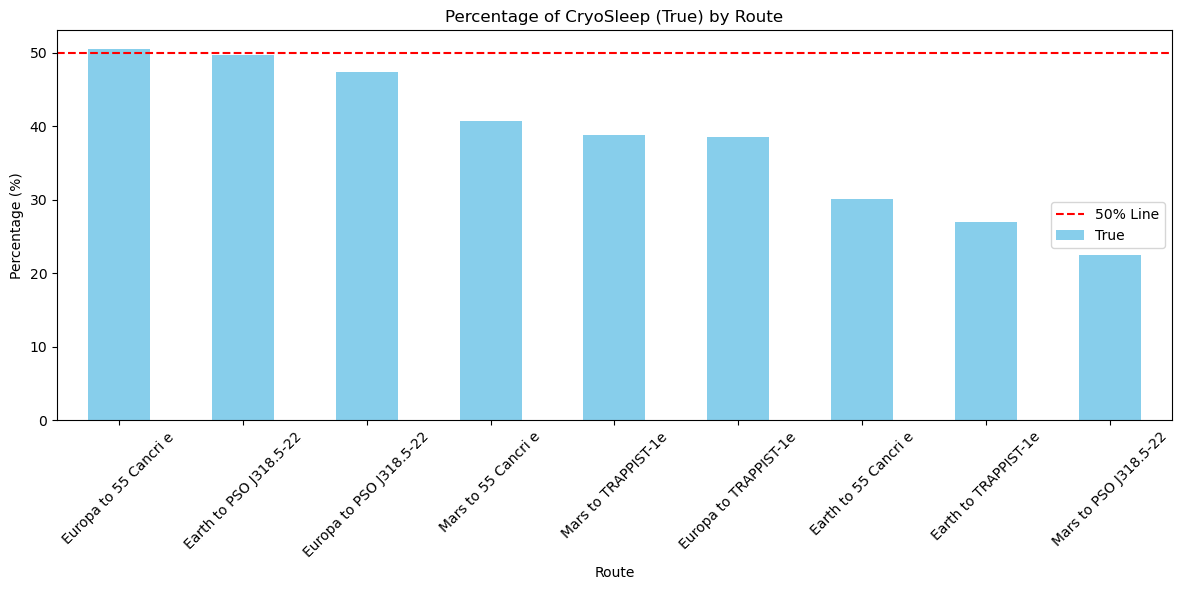

In [43]:
# 1. 이동 경로(Route) 컬럼 생성
train['Route'] = train['HomePlanet'] + " to " + train['Destination']

# 2. 경로별 동면 비율 계산
# 각 경로(Route) 내에서 CryoSleep의 True/False 비율을 구합니다.
route_cryo_pivot = train.groupby('Route')['CryoSleep'].value_counts(normalize=True).unstack() * 100

# 결측치를 0으로 채워 보기 좋게 정렬
route_cryo_pivot = route_cryo_pivot.fillna(0)

print("--- [경로별 동면(CryoSleep) 비율 (%)] ---")
print(route_cryo_pivot)

# 3. 시각화 (어떤 경로에서 동면을 많이 하는가?)
plt.figure(figsize=(12, 6))
route_cryo_pivot[True].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.axhline(y=50, color='r', linestyle='--', label='50% Line')
plt.title('Percentage of CryoSleep (True) by Route')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
### 1-1-5-3 경로별 지출내역도 확인

--- [경로별 TotalSpend 분석] ---
                                mean       median  count
Route                                                   
Europa to PSO J318.5-22  4139.337214  1894.030435     19
Europa to 55 Cancri e    3631.698880     0.000000    905
Europa to TRAPPIST-1e    3301.733370  2152.000000   1221
Mars to 55 Cancri e      1188.184003   783.000000    197
Mars to PSO J318.5-22    1057.624041   912.500000     50
Mars to TRAPPIST-1e      1055.370355   955.000000   1525
Earth to TRAPPIST-1e      750.644484   783.000000   3143
Earth to 55 Cancri e      639.988653   652.000000    697
Earth to PSO J318.5-22    473.190827     0.000000    725


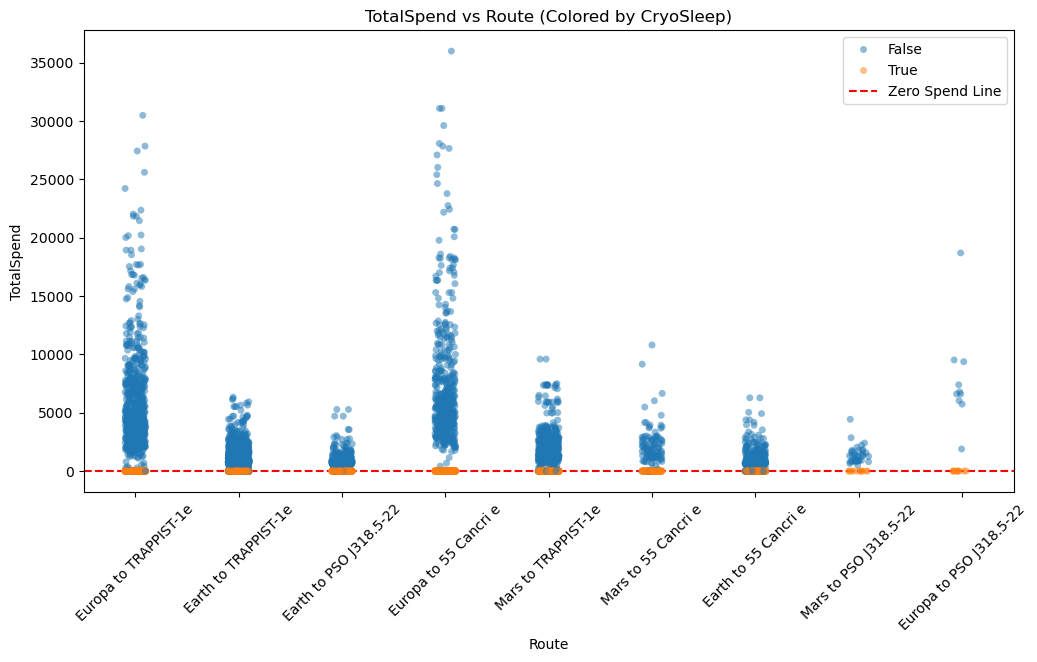

In [46]:
# 1. 경로별 지출 통계 (평균 지출액 중심)
# TotalSpend가 높은 경로일수록 '지출 0'인 승객이 동면(CryoSleep)일 확률이 급격히 높아집니다.
route_spend_analysis = train.groupby('Route')['TotalSpend'].agg(['mean', 'median', 'count']).sort_values(by='mean', ascending=False)

print("--- [경로별 TotalSpend 분석] ---")
print(route_spend_analysis)

# 2. 시각화: 지출액과 동면 여부의 상관관계 확인
plt.figure(figsize=(12, 6))
sns.stripplot(data=train, x='Route', y='TotalSpend', hue='CryoSleep', jitter=True, alpha=0.5)
plt.title('TotalSpend vs Route (Colored by CryoSleep)')
plt.xticks(rotation=45)
plt.axhline(y=1, color='r', linestyle='--', label='Zero Spend Line') # 지출 0원 선
plt.legend()
plt.show()

### 두 그래 프 분석
동면 vs 경로를 보면 경로마다 큰차이가 없어보이고
지출 vs 경로를 보면 경로마다 뚜렷한 큰 차이가 보입니다. 제 직관에 의하면 지출이 거리랑 관련이 클것같습니다. 하지만 이미 지출값은 평균값으로 채웠고

이제 동면여부는 다른방법을 생각해야겠네요...

출발지와 도착지만가지고 비교를 해봐야겠네요

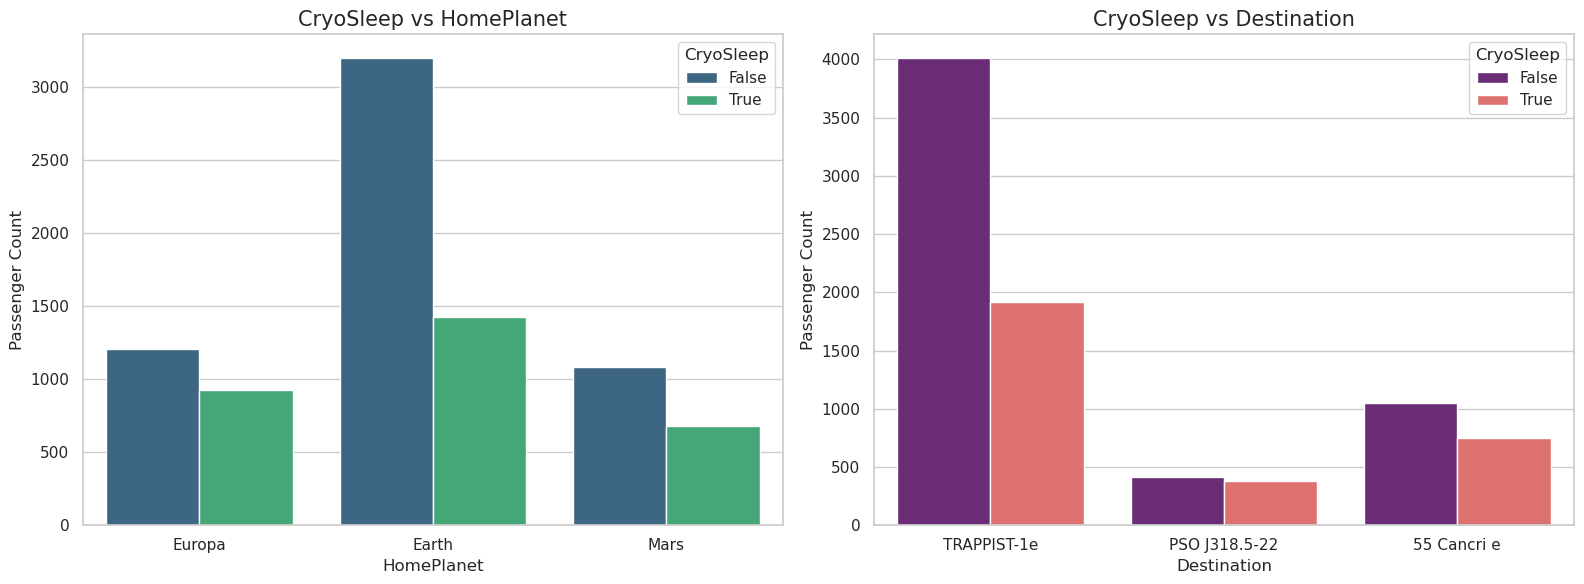

In [47]:
# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# [그래프 1] 출발지(HomePlanet)별 동면 여부
plt.subplot(1, 2, 1)
sns.countplot(data=train, x='HomePlanet', hue='CryoSleep', palette='viridis')
plt.title('CryoSleep vs HomePlanet', fontsize=15)
plt.xlabel('HomePlanet')
plt.ylabel('Passenger Count')

# [그래프 2] 도착지(Destination)별 동면 여부
plt.subplot(1, 2, 2)
sns.countplot(data=train, x='Destination', hue='CryoSleep', palette='magma')
plt.title('CryoSleep vs Destination', fontsize=15)
plt.xlabel('Destination')
plt.ylabel('Passenger Count')

plt.tight_layout()
plt.show()

#### 대략 출발지가 Earth이거나 도착지가 TRAPPIST-1e면 동면 True 아니면 False로 하면 될거같네요

In [48]:
# train 데이터 처리
# 조건: (동면 여부가 NaN) AND (출발지가 Earth 이거나 도착지가 TRAPPIST-1e)
mask_train = (train['CryoSleep'].isnull()) & ((train['HomePlanet'] == 'Earth') | (train['Destination'] == 'TRAPPIST-1e'))
train.loc[mask_train, 'CryoSleep'] = True

train['CryoSleep'] = train['CryoSleep'].fillna(False)


# test 데이터 처리 (일관성을 위해 동일 로직 적용)
mask_test = (test['CryoSleep'].isnull()) & ((test['HomePlanet'] == 'Earth') | (test['Destination'] == 'TRAPPIST-1e'))
test.loc[mask_test, 'CryoSleep'] = True

test['CryoSleep'] = test['CryoSleep'].fillna(False)

print(f"train CryoSleep 결측치 남은 수: {train['CryoSleep'].isnull().sum()}")
print(f"test CryoSleep 결측치 남은 수: {test['CryoSleep'].isnull().sum()}")

train CryoSleep 결측치 남은 수: 0
test CryoSleep 결측치 남은 수: 0


In [49]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      111
CryoSleep         0
Cabin           199
Destination     103
Age             179
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpend        0
Route           211
dtype: int64


#### 1-1-6 멀리 돌아왔네요 -_- 다시 HomePlanet Destination으로.. 결국 Cabin처리

HomePlanet하고 Destination을 어떤값으로 채워야할지 알기가 어렵네요 혹시 PassengerId에 group번호가 영향이있을까요? 먼저 PassengerID 데이터 부터 체크해볼게요

In [50]:
# 1. Group 컬럼 생성 (문자열 형태)
train['Group'] = train['PassengerId'].apply(lambda x: x.split('_')[0])
test['Group'] = test['PassengerId'].apply(lambda x: x.split('_')[0])

# 2. 숫자형으로 변환하여 최소/최대값 확인
# (문자열 상태에서는 '9'가 '10'보다 크게 정렬될 수 있으므로 int 변환이 필요합니다)
train_group_ids = train['Group'].astype(int)
test_group_ids = test['Group'].astype(int)

print("--- [Train 데이터 그룹 범위] ---")
print(f"최소 그룹 번호: {train_group_ids.min():04d}")
print(f"최대 그룹 번호: {train_group_ids.max():04d}")
print(f"고유 그룹 수: {train['Group'].nunique()}개")

print("\n--- [Test 데이터 그룹 범위] ---")
print(f"최소 그룹 번호: {test_group_ids.min():04d}")
print(f"최대 그룹 번호: {test_group_ids.max():04d}")
print(f"고유 그룹 수: {test['Group'].nunique()}개")

# 3. 그룹별 인원 수 분포 확인 (상위 5개)
print("\n--- [가장 인원이 많은 그룹 TOP 5] ---")
print(train['Group'].value_counts().head(5))

--- [Train 데이터 그룹 범위] ---
최소 그룹 번호: 0001
최대 그룹 번호: 9280
고유 그룹 수: 6217개

--- [Test 데이터 그룹 범위] ---
최소 그룹 번호: 0013
최대 그룹 번호: 9277
고유 그룹 수: 3063개

--- [가장 인원이 많은 그룹 TOP 5] ---
Group
9081    8
4005    8
8988    8
5133    8
4256    8
Name: count, dtype: int64


#### 총 그룹은 6217가지가있는데 9280까지있는걸보니 출발지에따라 그룹수가 나눠져있는것같아요. 확인해볼게요

In [53]:
train['PassengerId'].head(20)

0     0001_01
1     0002_01
2     0003_01
3     0003_02
4     0004_01
5     0005_01
6     0006_01
7     0006_02
8     0007_01
9     0008_01
10    0008_02
11    0008_03
12    0009_01
13    0010_01
14    0011_01
15    0012_01
16    0014_01
17    0015_01
18    0016_01
19    0017_01
Name: PassengerId, dtype: object

#### 그룹 번호가 9280까지있는데 그룹수가 6217개밖에없다는건 그룹 번호가 순차적으로 증가하다가 특정상황에서 점프를한다는 이야기 이걸 binning 처리하면 뭔가 단서가 나올지도?

--- [ 그룹 ID 구간별 분포 분석 (총 6217개 그룹) ] ---
구간 0-928        : 실제 그룹  618개 존재
구간 928-1856     : 실제 그룹  615개 존재
구간 1856-2784    : 실제 그룹  635개 존재
구간 2784-3712    : 실제 그룹  614개 존재
구간 3712-4640    : 실제 그룹  642개 존재
구간 4640-5568    : 실제 그룹  625개 존재
구간 5568-6496    : 실제 그룹  640개 존재
구간 6496-7424    : 실제 그룹  603개 존재
구간 7424-8352    : 실제 그룹  618개 존재
구간 8352-9280    : 실제 그룹  607개 존재


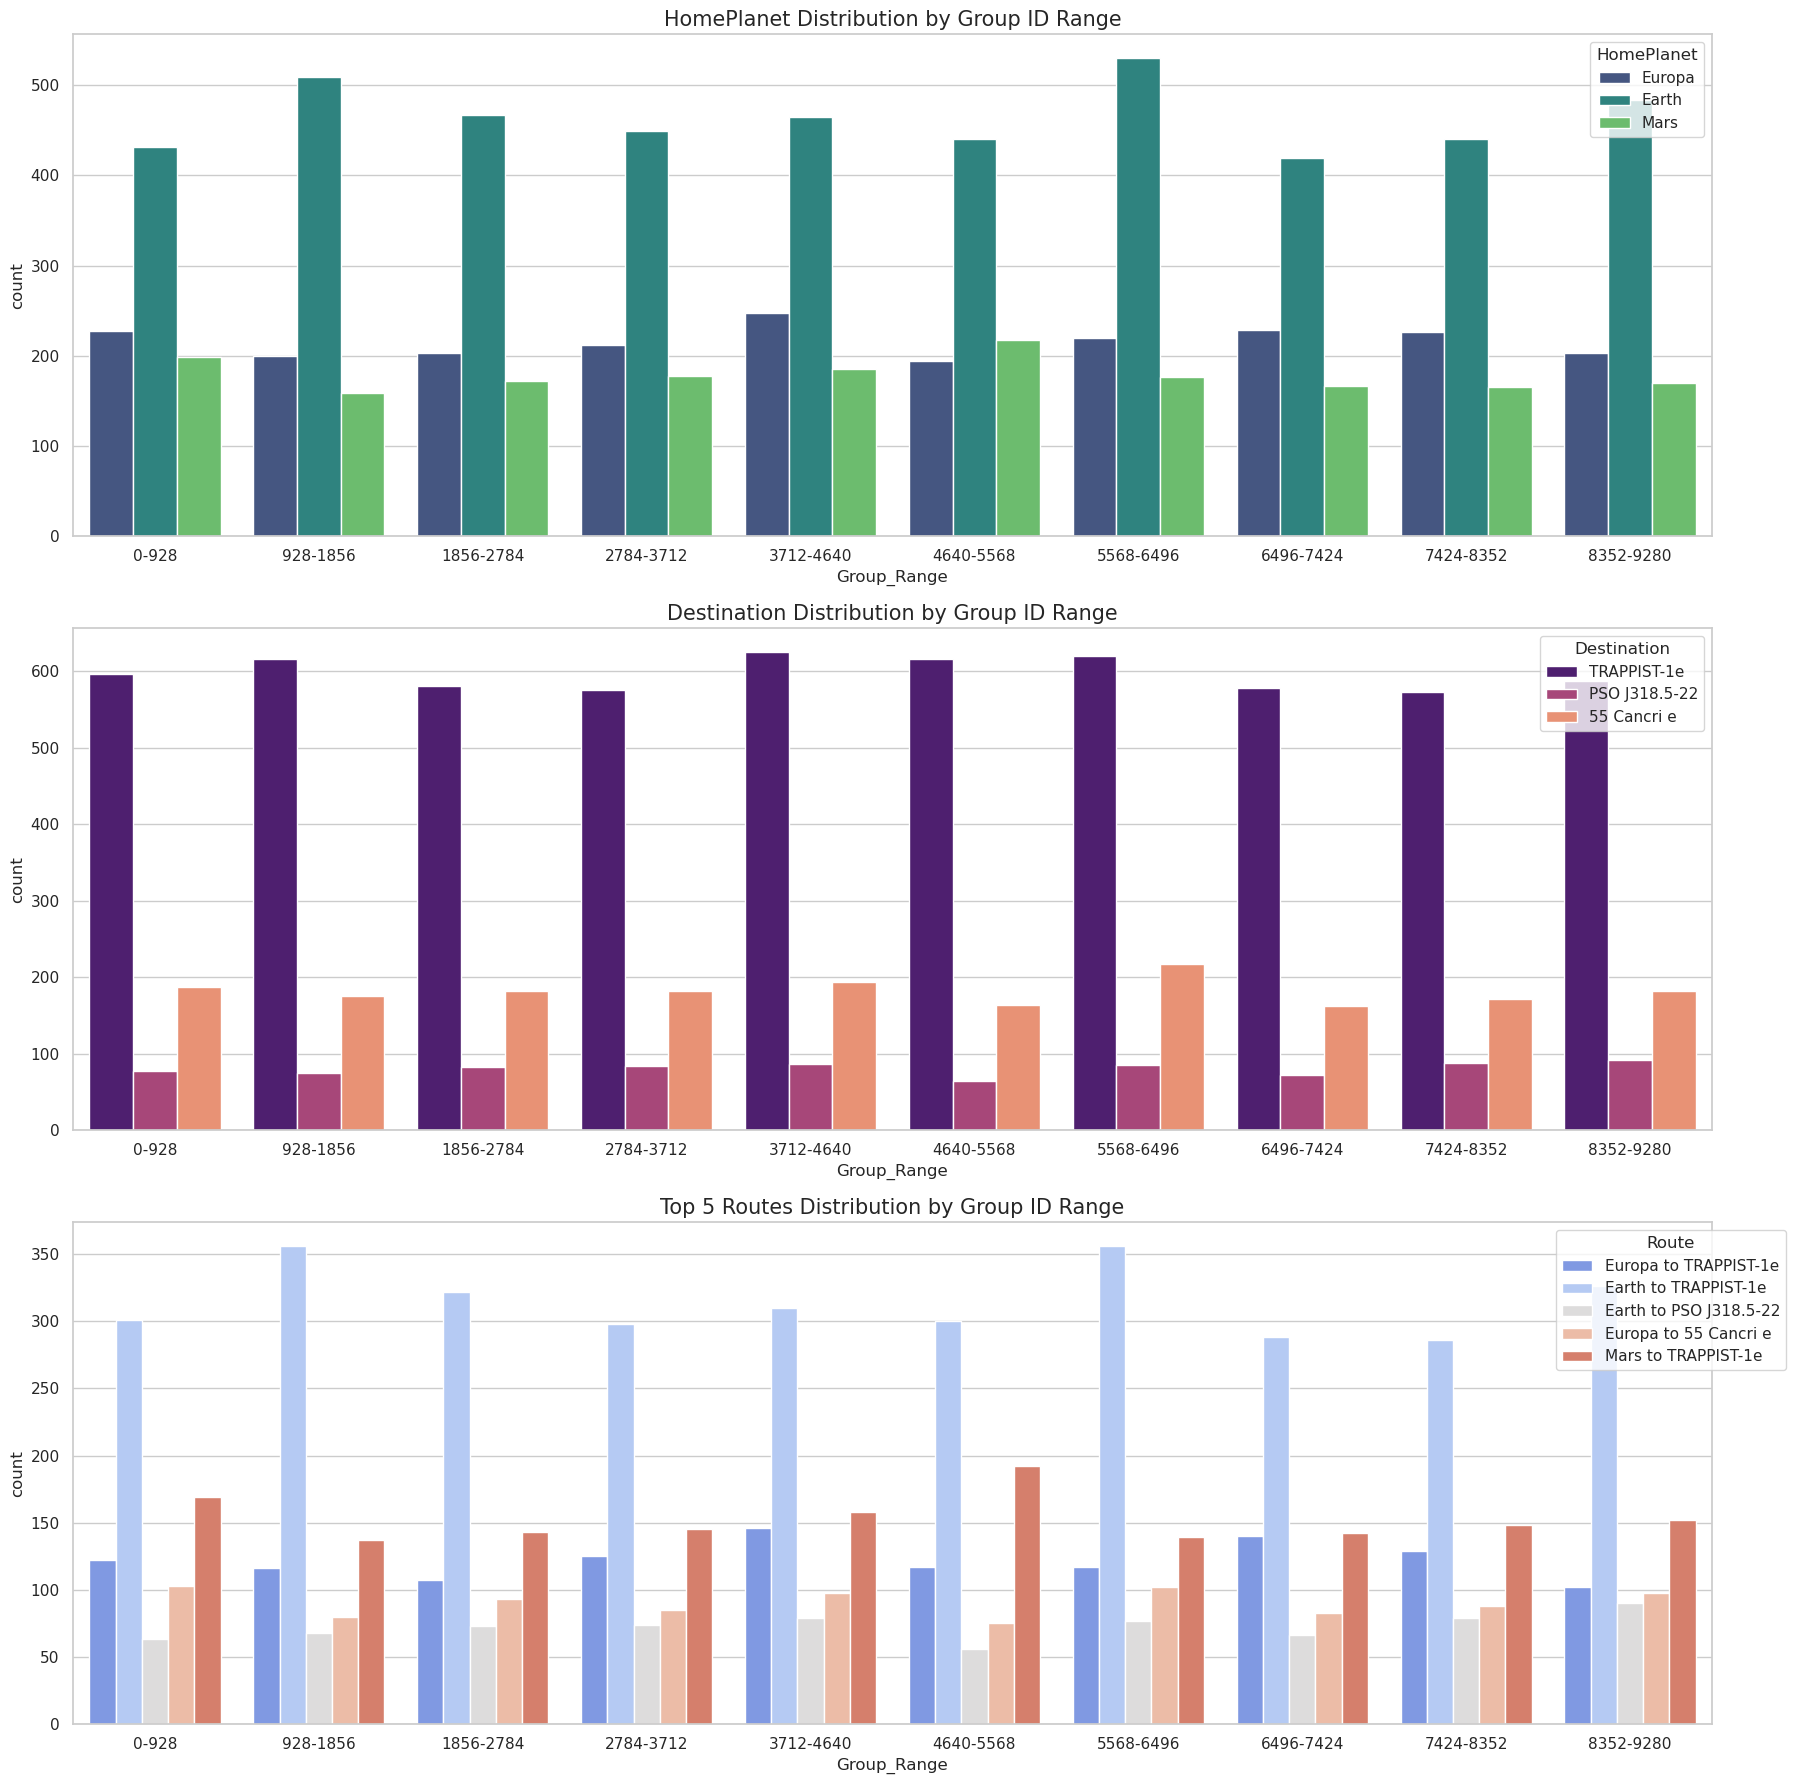

In [57]:
train['Group_Num'] = train['PassengerId'].apply(lambda x: int(x.split('_')[0]))

# 2. 구간(Bin) 생성: 0부터 9280까지를 10등분
# 범위를 9280 근처로 잡거나 데이터의 max값으로 잡습니다.
max_group = train['Group_Num'].max()
bins = np.linspace(0, max_group, 11) # 11개 지점을 찍어야 10개 구간이 생김
labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(10)]

# 3. Binning 적용
train['Group_Range'] = pd.cut(train['Group_Num'], bins=bins, labels=labels, include_lowest=True)

# 4. 결과 보고 (텍스트)
print(f"--- [ 그룹 ID 구간별 분포 분석 (총 {train['Group'].nunique()}개 그룹) ] ---")
group_distribution = train.groupby('Group_Range')['Group'].nunique()

for range_name, count in group_distribution.items():
    # 해당 구간에 실제 존재하는 그룹 수와, 번호상의 간격 내 밀도를 계산
    print(f"구간 {range_name:12} : 실제 그룹 {count:4}개 존재")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 18))

# 1. 그룹 구간 vs 출발지 (HomePlanet)
plt.subplot(3, 1, 1)
sns.countplot(data=train, x='Group_Range', hue='HomePlanet', palette='viridis')
plt.title('HomePlanet Distribution by Group ID Range', fontsize=15)
plt.legend(title='HomePlanet', loc='upper right')

# 2. 그룹 구간 vs 도착지 (Destination)
plt.subplot(3, 1, 2)
sns.countplot(data=train, x='Group_Range', hue='Destination', palette='magma')
plt.title('Destination Distribution by Group ID Range', fontsize=15)
plt.legend(title='Destination', loc='upper right')

# 3. 그룹 구간 vs 출발지-도착지 (Route)
# 노이즈를 줄이기 위해 상위 5개 주요 경로만 추출해서 비교합니다.
top_routes = train['Route'].value_counts().nlargest(5).index
train_top_routes = train[train['Route'].isin(top_routes)]

plt.subplot(3, 1, 3)
sns.countplot(data=train_top_routes, x='Group_Range', hue='Route', palette='coolwarm')
plt.title('Top 5 Routes Distribution by Group ID Range', fontsize=15)
plt.legend(title='Route', loc='upper right', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

#### 그룹 번호가 출발지 도착지랑 전혀상관없이 고르게 분포되어있는걸 확인했습니다.

#### 그룹번호를 나머지 결측치 cabin 이랑 age랑도 비교해볼게요

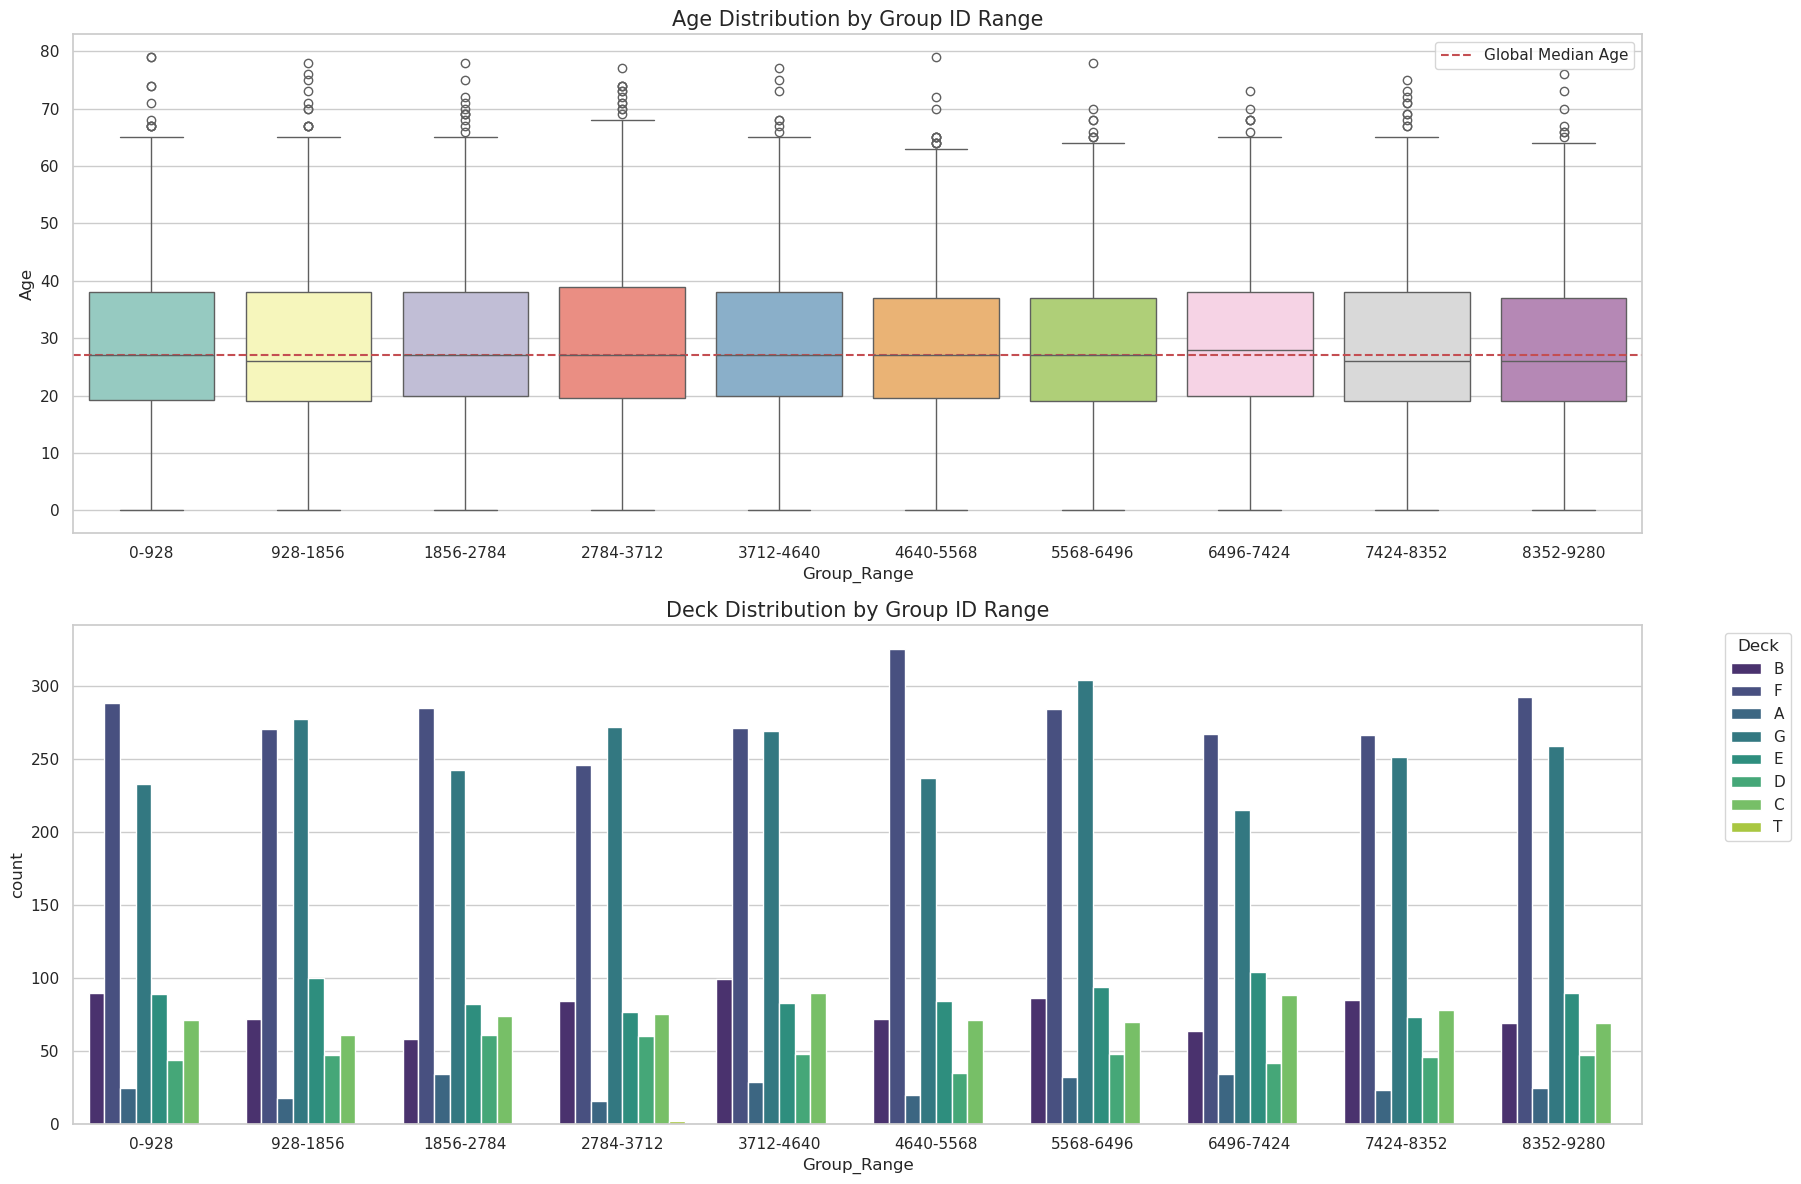

In [58]:
# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# [그래프 1] 그룹 구간 vs 나이 (Age)
# 나이는 연속형 변수이므로 Boxplot이나 Violinplot으로 분포를 봅니다.
plt.subplot(2, 1, 1)
sns.boxplot(data=train, x='Group_Range', y='Age', palette='Set3')
plt.title('Age Distribution by Group ID Range', fontsize=15)
plt.axhline(train['Age'].median(), color='r', linestyle='--', label='Global Median Age')
plt.legend()

# [그래프 2] 그룹 구간 vs 객실 구역 (Deck)
# Cabin에서 Deck을 추출한 상태여야 합니다. (A, B, C, D, E, F, G, T)
if 'Deck' not in train.columns:
    train['Deck'] = train['Cabin'].str.split('/').str[0]

plt.subplot(2, 1, 2)
sns.countplot(data=train, x='Group_Range', hue='Deck', palette='viridis')
plt.title('Deck Distribution by Group ID Range', fontsize=15)
plt.legend(title='Deck', loc='upper right', bbox_to_anchor=(1.1, 1))

plt.tight_layout()
plt.show()

#### 그룹 번호에따라 Age랑 Cabin에서도 눈에띄는 차이는 찾을수 없습니다.

#### 남은 결측치를 다시한번 확인

In [59]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      111
CryoSleep         0
Cabin           199
Destination     103
Age             179
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpend        0
Route           211
Group_Num         0
Group_Range       0
Deck            199
dtype: int64


#### 같은 그룹은 같은 cabin사용하는것으로 채우고, 그래도 빈값은 최빈값으로 채움

In [60]:
for df in [train, test]:
    # 1. Cabin 분리 (결측치는 임시로 'Unknown')
    df['Cabin'] = df['Cabin'].fillna('U/0/U')
    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0])
    df['Side'] = df['Cabin'].apply(lambda x: x.split('/')[2])
    
    # 2. 'U'(Unknown)를 다시 NaN으로 돌려놓고 그룹 최빈값 적용
    df.loc[df['Deck'] == 'U', ['Deck', 'Side']] = np.nan
    for col in ['Deck', 'Side']:
        # 같은 그룹은 보통 같은 구역에 머뭅니다.
        df[col] = df[col].fillna(df.groupby('Group')[col].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))
        # 최종 마무리 (전체 최빈값)
        df[col] = df[col].fillna(train[col].mode()[0])

In [61]:
print(train.isnull().sum())

PassengerId       0
HomePlanet      111
CryoSleep         0
Cabin             0
Destination     103
Age             179
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpend        0
Route           211
Group_Num         0
Group_Range       0
Deck              0
Side              0
dtype: int64


#### 1-1-7 멀리 돌아왔네요 -_- 진짜 마지막 HomePlanet Destination으로..

HomePlanet하고 Destination을 최빈값으로 채우겠습니다.

In [62]:
for col in ['HomePlanet', 'Destination']:
    # 1. Train 데이터의 최빈값 계산
    mode_value = train[col].mode()[0]
    
    # 2. Train과 Test의 결측치를 해당 값으로 채움
    train[col] = train[col].fillna(mode_value)
    test[col] = test[col].fillna(mode_value)

# 결과 확인
print("--- [ 결측치 처리 후 현황 ] ---")
print(f"HomePlanet 결측치: {train['HomePlanet'].isnull().sum()}")
print(f"Destination 결측치: {train['Destination'].isnull().sum()}")

--- [ 결측치 처리 후 현황 ] ---
HomePlanet 결측치: 0
Destination 결측치: 0


#### 1-1-8 마지막 Age는 지출한내역에 비례하게 채우겠습니다.

VIP를 2000으로 구분했던걸생각하면 달러보다는 훨씬 큰단위일것같은데 그래도 장기여행이니까 아이들도 간식이나 오락비용으로 지출을 상당히할수있을거같아요 
대충감으로 300이하면 청소년에서 20살정도 그이상이면 성인으로 생각하고 median값을 넣어줄게요

In [63]:
# 1. 기준점 설정
threshold = 300

# 2. 각 그룹별 나이 중앙값 계산 (Train 데이터 기준)
# 소액 지출자 그룹의 중앙값 (보통 10대 후반~20대 초반이 나옵니다)
under_median = train[train['TotalSpend'] <= threshold]['Age'].median()

# 고액 지출자 그룹의 중앙값 (보통 30대 이상이 나옵니다)
over_median = train[train['TotalSpend'] > threshold]['Age'].median()

print(f"소액 지출자(<= {threshold}) 나이 중앙값: {under_median}")
print(f"고액 지출자(> {threshold}) 나이 중앙값: {over_median}")

# 3. 결측치 채우기 로직 적용
for df in [train, test]:
    # 조건 1: 나이가 비어있고, 지출이 기준치 이하인 경우
    df.loc[(df['Age'].isnull()) & (df['TotalSpend'] <= threshold), 'Age'] = under_median
    
    # 조건 2: 나이가 비어있고, 지출이 기준치 초과인 경우
    df.loc[(df['Age'].isnull()) & (df['TotalSpend'] > threshold), 'Age'] = over_median
    
    # 정수형 유지를 위해 반올림 후 변환 (나이는 보통 정수로 관리함)
    df['Age'] = df['Age'].round().astype(int)

print(f"Age 결측치 처리 완료! 남은 개수: {train['Age'].isnull().sum()}")

소액 지출자(<= 300) 나이 중앙값: 24.0
고액 지출자(> 300) 나이 중앙값: 29.0
Age 결측치 처리 완료! 남은 개수: 0


In [65]:
print(train.isnull().sum())
print(test.isnull().sum())

PassengerId       0
HomePlanet        0
CryoSleep         0
Cabin             0
Destination       0
Age               0
VIP               0
RoomService       0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Name            200
Transported       0
Group             0
TotalSpend        0
Route           211
Group_Num         0
Group_Range       0
Deck              0
Side              0
dtype: int64
PassengerId      0
HomePlanet       0
CryoSleep        0
Cabin            0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Name            94
Group            0
TotalSpend       0
Deck             0
Side             0
dtype: int64


## 1-2. Feature Enginnering

In [66]:
from sklearn.model_selection import train_test_split

target_features = [
    'HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 
    'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 
    'TotalSpend', 'Deck', 'Side'
]

X = train[target_features].copy()
y = train['Transported'].astype(int)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Transformer로 원핫인코딩및 scale처리

In [68]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. 범주형과 수치형 컬럼 구분
cat_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
num_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'TotalSpend']

# 2. 전처리 도구 설정 (ColumnTransformer 사용 시 원본 보존하며 변환 용이)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# 3. 학습 데이터로 기준 잡기 (fit) 및 변환 (transform)
X_train_scaled = preprocessor.fit_transform(X_train)

# 4. 검증 데이터는 '학습 데이터 기준'으로 변환만 수행
X_val_scaled = preprocessor.transform(X_val)

## 2. 모델 훈련

## 2-1-1 RF+Grid v1

In [ ]:
## from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# 2. 탐색할 하이퍼파라미터 후보군 설정
param_grid = {
    'n_estimators': [100, 200, 300],      # 나무의 개수
    'max_depth': [None, 10, 20],          # 나무의 최대 깊이
    'min_samples_split': [2, 5, 10],      # 노드 분할을 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],        # 리프 노드의 최소 샘플 수
    'max_features': ['sqrt', 'log2']      # 최적 분할을 위해 고려할 피처 개수
}

# 3. 기본 모델 생성
rf = RandomForestClassifier(random_state=42)

# 4. GridSearchCV 설정
# cv=5: 5-Fold 교차 검증
# n_jobs=-1: 모든 CPU 코어 사용 (병렬 처리)
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid, 
    cv=5,
    n_jobs=-1, 
    verbose=2, 
    scoring='accuracy'
)

# 5. 그리드 서치 수행 
grid_search.fit(X_train_scaled, y_train)

# 6. 결과 확인
print("-" * 30)
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"최고 교차 검증 점수(Train CV): {grid_search.best_score_:.4f}")

# 7. 최적의 모델로 검증 데이터(X_val_scaled) 평가
best_model = grid_search.best_estimator_
val_score = best_model.score(X_val_scaled, y_val)
print(f"검증 데이터 실제 정확도(Validation): {val_score:.4f}")

## 2-1-2 RF+Grid v2

v1 값 은 위에 코드 돌렸는데 마크다운으로 바뀌면서 결과값 날라감.

param_grid = {
    'n_estimators': [100, 200, 300],      # 나무의 개수
    'max_depth': [None, 10, 20],          # 나무의 최대 깊이
    'min_samples_split': [2, 5, 10],      # 노드 분할을 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],        # 리프 노드의 최소 샘플 수
    'max_features': ['sqrt', 'log2']      # 최적 분할을 위해 고려할 피처 개수
}

최적의 파라미터: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
최고 교차 검증 점수(Train CV): 0.8080
검증 데이터 실제 정확도(Validation): 0.7964

거의 최대값이 나와서 v2에서는 상향조정

In [71]:
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import GridSearchCV

# 2. 탐색할 하이퍼파라미터 후보군 설정
param_grid_v2 = {
    'n_estimators': [250, 350, 450],      # 나무의 개수
    'max_depth': [20, 30],          # 나무의 최대 깊이
    'min_samples_split': [7, 13, 19],      # 노드 분할을 위한 최소 샘플 수
    'min_samples_leaf': [3,5,7],        # 리프 노드의 최소 샘플 수
    'max_features': ['sqrt', 'log2']      # 최적 분할을 위해 고려할 피처 개수
}

# 3. 기본 모델 생성
rf = RandomForestClassifier(random_state=42)

# 4. GridSearchCV 설정
# cv=5: 5-Fold 교차 검증
# n_jobs=-1: 모든 CPU 코어 사용 (병렬 처리)
grid_search = GridSearchCV(
    estimator=rf, 
    param_grid=param_grid_v2, 
    cv=5,
    n_jobs=-1, 
    verbose=2, 
    scoring='accuracy'
)

# 5. 그리드 서치 수행 
grid_search.fit(X_train_scaled, y_train)

# 6. 결과 확인
print("-" * 30)
print(f"최적의 파라미터: {grid_search.best_params_}")
print(f"최고 교차 검증 점수(Train CV): {grid_search.best_score_:.4f}")

# 7. 최적의 모델로 검증 데이터(X_val_scaled) 평가
best_model = grid_search.best_estimator_
val_score = best_model.score(X_val_scaled, y_val)
print(f"검증 데이터 실제 정확도(Validation): {val_score:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=7, n_estimators=250; total time=   3.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=7, n_estimators=250; total time=   2.8s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=7, n_estimators=350; total time=   4.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=7, n_estimators=350; total time=   4.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=7, n_estimators=350; total time=   3.9s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=7, n_estimators=450; total time=   5.3s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=7, n_estimators=450; total time=   5.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=3, min_samples_split=13, n_estimators=

In [ ]:
#----------------------------------------------------------------------------------------------

### 2-1-2 RF+Grid v2 결과

최적의 파라미터: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 13, 'n_estimators': 450}

최고 교차 검증 점수(Train CV): 0.8085

검증 데이터 실제 정확도(Validation): 0.7959

오히려 결과가 더 안좋아졌습니다 첫번째 찾은 최적값으로 RF모델을 전체데이터로 훈련시키겠습니다.

### 2-2 최적값으로 RF모델 재훈련

In [72]:
from sklearn.ensemble import RandomForestClassifier

# 1. 그리드 서치에서 찾은 최적의 파라미터 설정
best_params = {
    'max_depth': 20,
    'max_features': 'sqrt',
    'min_samples_leaf': 4,
    'min_samples_split': 10,
    'n_estimators': 300,
    'random_state': 42  
}

# 2. 최적 파라미터로 모델 생성
final_rf_model = RandomForestClassifier(**best_params)

# 3. 모델 훈련 (전처리된 X_train_scaled 사용)
final_rf_model.fit(X_train_scaled, y_train)

# 4. 성능 평가
train_score = final_rf_model.score(X_train_scaled, y_train)
val_score = final_rf_model.score(X_val_scaled, y_val)

print(f"최종 모델 학습 데이터 점수: {train_score:.4f}")
print(f"최종 모델 검증 데이터 점수: {val_score:.4f}")

최종 모델 학습 데이터 점수: 0.8697
최종 모델 검증 데이터 점수: 0.7964


## 3. 데이터 예측 및 제출

In [74]:
# 테스트 데이터 예측

X_test = test[target_features].copy()

X_test_scaled = preprocessor.transform(X_test)
final_predictions = final_rf_model.predict(X_test_scaled)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": final_predictions.astype(bool) # 0, 1을 다시 True, False로 변환
})

# 6. CSV 파일로 저장
submission.to_csv('submission.csv', index=False)

print("제출 파일 'submission.csv'가 성공적으로 생성되었습니다!")


제출 파일 'submission.csv'가 성공적으로 생성되었습니다!


## 4. Kaggle 결과
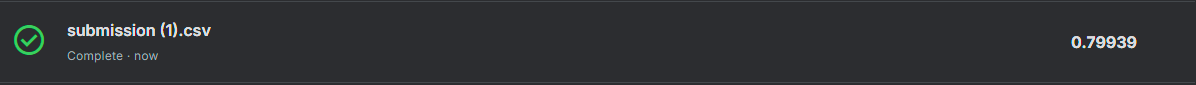

# 5. 데이터 분석 및 모델 학습 회고
- 지금까지 여러가지 모델학습 Practice를해봤지만 이번처럼 결측치가 많은 모델학습은 처음인것같습니다. 거의 모든 카테고리에서 결측치가 무시할수 없는 수준으로 존재하여, 무엇부터 채워야하지? 라는 생각과 함께 당황했지만, 그래도 거듭 생각하다보니 실마리가 보이기 시작하고 1-1-6 까지는 어느정도 논리적으로 채웠다고 생각합니다. 하지만 그뒤로 1-1-7, 1-1-8 두가지는 시간부족으로 충분히 생각하지못하고 최빈값으로 채운게 많이 아쉽습니다. 이번에 전처리만 4시간이상 소요되었는데, 다음엔 시간관리를 더 잘해야겠다 생각합니다.
- 반복되는 연습으로 이제 어느정도 모델학습의 Flow가 이해되었다고 생각했는데 회귀모델만 연습하다가, 분류모델을 작업하게되니 약간 다른부분때문에 다시 강의자료를 찾아보게 되더군요. 연습을 더 하는것도 중요하지만, 절차를 정리하는시간을 길게 가져보는것도 크게 도움될것 같습니다.
- 이제는 이론수업에서 헷갈렸던 용어들이 잘 이해가기 시작하고, 분류모델과 회귀모델의 절차가 다르고 모델 검증하는방법에서 차이나는것도 조금 이해됩니다. 전처리 -> Feature 엔지니어링 -> 모델훈련 -> 예측 이 순서는 완전히 와닿아 절대 까먹지 않을것 같습니다.
- 완벽하진않지만 또 충분한 시간을 들인건 아니지만 Kaggle에서 실제로 프로젝트 참여해보고 제출해서 점수받아본게 좋은경험인거 같습니다. 제출도 여러번해보니 처음엔 오래걸렸지만 이제 제출하는건 금방금방 되는것 같습니다.
- 이 프로젝트와는 관계없지만 엄청 중요했던게 주피터 노트북환경... 코드가 순서대로 실행되지만 위에있는 cell로 돌아가서 수정하면 원리상 문제가 없지만 주피터 서버가 다운되었을때, 처음부터 다시 컴파일하면 에러가 날수있습니다. 수정사항이 생기면 꼭 아래있는 셀에 새로 추가해야한다는것. 꼭 기억해야할것 같습니다.
- 향후에도 머신러닝 학습을 더 해볼기회가 있으면 좋겠습니다.
- 이번프로젝트에서 머신러닝 학습에 있어서 앞으로 가장 필요하다고 느낀건 '전처리 능력 키우기' 입니다. 어차피 모델은 완전 새로운개념을 만들어내지않는이상 어느정도 정해져있고 하이퍼파라미터 최적화 하는과정도 뻔합니다. (아닐수도?) 하지만 전처리과정에서는 인간의 지혜와 상식과, 지식, 직관이 필요하기도하고 데이터 형태나 결측치 종류, 결측치의 양에따라 전처리하는방법이 엄청 많을것같습니다. 나중엔 AI가 이것도 해줄수있겠지만, AI가 데이터를 직접 보고하는게 아닌이상 쉽지않고, 데이터를 보더라도 용량이 너무크면 AI가 인간을 따라잡는데는 시간이 좀 걸릴것 같습니다.

# 6. Reference

- 아이펠 강의자료
- 캐글 튜토리얼 블로그(https://kaggle-kr.tistory.com/17#1_2)


# 7. Etc
- 파이썬 코드작성에 AI도움을 받음.
- 뭘 할지는 직접생각함.
- 전처리할때 도움받으려 시도했지만 AI가 추천해준방법중 의미있게 결측치를 채우는데 있어서 효과가 없었음.